# C12 · Code walkthrough: `mission/` and `requirements/` (segments, the mission chain, cost, capability points)

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). This notebook covers what is *flown* (segments chained into a mission), what must be *possible*
(capability requirements) and what it *costs* (cost per mission), plus the two places in `examples/halo_sizing.py`
that use them for the Halo: `halo_mission` and the cost block.

| Module | Lines | What it holds |
|---|---|---|
| `mission/segments.py` | 127 | five frozen segment dataclasses (hover, climb, cruise, loiter, descent), each a flight condition plus a duration; `ground_distance_m` |
| `requirements/capability.py` | 84 | four capability requirements (hover, climb, speed, ceiling) as flight conditions with no duration; `RequirementSet` |
| `mission/mission.py` | 148 | `Mission`, `SegmentResult`, `MissionResult`, `build_mission`: chains flight points, mass, SOC, RC voltages and temperatures |
| `mission/cost.py` | 93 | `CostModel.evaluate` → `CostBreakdown`: capital + fuel + ground electricity + battery wear + time, per mission |
| `examples/halo_sizing.py` L901-914, L1306-1323 | 14 + 18 | `halo_mission` (the design mission) and the cost-per-mission block of the sizing |

**Who imports them (grep of `src`, `examples`, `tests`):**
- `segments.py`: `examples/halo_sizing.py`, `examples/mission_analysis.py`, `tests/mission/test_mission*.py`,
  `tests/performance/test_flight_point_redundancy.py`, `test_flight_point_thermal.py`, `test_hot_day_point.py`.
- `mission.py`: the same, plus `examples/coupled_sizing.py`.
- `cost.py`: only `examples/halo_sizing.py` and `tests/mission/test_cost.py`.
- `capability.py`: `examples/halo_sizing.py`, `requirements_sizing.py`, `coupled_sizing.py`, and tests.

**What they import:** `segments.py` and `capability.py` import only `FlightCondition` (`performance/flight_point.py`,
C11). `mission.py` imports `margin_above` (C01), `build_flight_point` (C11), `EquivalentCircuitBattery`,
`battery_for_condition` (redundancy) and `coolant_temperatures_C` (thermal). `cost.py` imports nothing from the
package: it is plain arithmetic.

Design logs: `docs/decisions/008` (requirements), `009` (segments, prescribed and semi-free missions), `010`
(coupled sizing), `017` (in-flight recharge, SOC floor every segment), `021` (ECM battery, sub-segments), `028`
(thermal history), `029` (cost).

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

import time
from dataclasses import replace, fields
from examples.halo_sizing import (HaloRequirements, build_halo_aircraft, build_halo_aerodynamics, halo_mission,
                                  soc_take_off, soc_minimum, soc_emergency_floor, fuel_factor, temperature_offset_K)
ref = baseline()
assumptions = baseline_assumptions()
requirements = HaloRequirements()
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)
aero = build_halo_aerodynamics(requirements, assumptions)
instances = aircraft.powertrain.topology.instances
print(f"sized Halo: MTOM {ref.mass_takeoff_kg:.1f} kg, empty {ref.mass_empty_kg:.1f} kg, fuel {ref.mass_fuel_kg:.1f} kg, "
      f"battery {ref.energy_battery_kWh:.2f} kWh, cruise {ref.velocity_cruise_m_s:.2f} m/s, loiter {ref.velocity_loiter_m_s:.2f} m/s")

sized Halo: MTOM 6885.1 kg, empty 5048.6 kg, fuel 936.4 kg, battery 69.99 kWh, cruise 85.13 m/s, loiter 68.89 m/s


---
## 1. `mission/segments.py`

The bottom of the stack. A segment knows two things: its duration and the flight condition of one point at a given
SOC. It builds no variables and writes no constraints.

In [2]:
show_source("src/aircraft_closure/mission/segments.py", 1, 41)

# src/aircraft_closure/mission/segments.py  lines 1-41
   1  """Quasi-steady mission segments (architecture level M1).
   2  
   3  Each segment maps to one Tier 7 flight condition plus a duration. Speeds,
   4  altitudes, distances and electric power fractions may be Opti variables, which
   5  is how missions become (semi-)free. Hover segments stand for vertical take-off
   6  and landing phases at T/W = 1; climb and descent are evaluated at their mean
   7  altitude.
   8  """
   9  from dataclasses import dataclass
  10  from typing import Any
  11  
  12  import aerosandbox.numpy as np
  13  
  14  from aircraft_closure.performance.flight_point import FlightCondition
  15  
  16  
  17  @dataclass(frozen=True)
  18  class HoverSegment:
  19      duration_s_given: Any = 60.0
  20      altitude_m: Any = 0.0
  21      hybridization_electric: Any = None
  22      label: str = "hover"
  23      temperature_offset_K: Any = 0.0            # Tier 16: ISA + offset at the altitude
  24     

**L1-8 docstring.** "Architecture level M1" refers to the mission ladder of `docs/ARCHITECTURE.md`: M0 a flight
point, M1 a segment, M2 a prescribed mission, M3 a semi-free mission, M4 trajectory dynamics (separate tool, plan
019). The key sentence is L3-5: speeds, altitudes, distances and electric fractions *may be Opti variables*. That is
the whole mechanism of a semi-free mission. No special code: a field typed `Any` that receives a CasADi symbol
propagates into the duration and the flight condition.

**L9-14 imports.** `aerosandbox.numpy` (so `sqrt` works on floats and symbols) and `FlightCondition` only.

**L17-40 `HoverSegment`** (frozen dataclass, so a segment is a value and can be reused in several missions).
- **L19** `duration_s_given = 60 s`. The field is named `_given` because `duration_s` is the method (L30-31) that
  every segment exposes; hover and loiter return the given value, the others compute it.
- **L20** altitude [m], **L21** `hybridization_electric`: `None` leaves the battery share free (an Opti variable
  created inside the flight point, bounded below by `hybridization_electric_min`); a number prescribes it.
- **L23** `temperature_offset_K`: ISA + offset (Tier 16, plan 020).
- **L24** `active_generator_count`: fewer generators models a turbogenerator out (Tier 17 engine-out reserve).
- **L26-28** Tier 18 failure states (plan 032): active lanes per rotor, active battery strings, failed buses. Only
  `HoverSegment` carries them: failures are assessed in hover, the most demanding case.
- **L33-40 `flight_condition(soc)`**: mode `"hover"`, velocity 0, **thrust-to-weight 1** (a hover segment is the
  vertical phase of take-off or landing, not a capability margin; the T/W 1.05 margin is a *requirement*, Section 2).
  `soc` is passed in because it is the chained state: the segment does not own it, the mission does.

In [3]:
show_source("src/aircraft_closure/mission/segments.py", 43, 116)

# src/aircraft_closure/mission/segments.py  lines 43-116
  43  @dataclass(frozen=True)
  44  class ClimbSegment:
  45      altitude_start_m: Any = 0.0
  46      altitude_end_m: Any = 1000.0
  47      climb_rate_m_s: Any = 4.0
  48      velocity_m_s: Any = 50.0
  49      hybridization_electric: Any = None
  50      label: str = "climb"
  51      temperature_offset_K: Any = 0.0            # Tier 16: ISA + offset at the altitude
  52  
  53      def duration_s(self):
  54          return (self.altitude_end_m - self.altitude_start_m) / self.climb_rate_m_s
  55  
  56      def flight_condition(self, soc):
  57          return FlightCondition(velocity_m_s=self.velocity_m_s, altitude_m=(self.altitude_start_m + self.altitude_end_m) / 2,
  58                                 climb_rate_m_s=self.climb_rate_m_s, soc=soc,
  59                                 hybridization_electric=self.hybridization_electric, label=self.label,
  60                                 temperature_offset_K=self.temperatu

The four airplane-mode segments share one pattern: geometry fields, an optional battery share, a label, an ISA
offset; `duration_s()` and `flight_condition(soc)`. They never set `mode`, so it is the `FlightCondition` default
`"airplane"`.

- **L43-60 `ClimbSegment`.**
  $$t_{climb} = \frac{h_{end} - h_{start}}{\dot h}$$
  (L53-54) in s, with the climb rate in m/s. The point is evaluated at the **mean altitude** (L57) with
  `climb_rate_m_s` set, so the flight point balances thrust = D + W sin γ with sin γ = climb rate / V
  (`flight_point.py`, C11). `velocity_m_s` is the **flight-path** speed, not the ground speed.
- **L63-78 `CruiseSegment`.** `t = distance / V` (L72-73). If V is an Opti variable the duration is symbolic, and so
  are the fuel burnt (flow × t) and the SOC drop. That is how cruise speed becomes a trade without any extra code.
- **L81-96 `LoiterSegment`.** A given duration (default 1,200 s) at a free or given speed. Level flight (no climb rate).
- **L99-116 `DescentSegment`.** `t = (h_start − h_end) / descent rate` (L109-110), and the flight condition gets
  `climb_rate_m_s = −descent_rate` (L114): the descent rate is stored positive, the sign is applied once here.
  At 5 m/s and 80 m/s the required thrust is D − W·sin|γ|, which can approach zero; `build_mission` guards the
  actuator-disk validity with thrust ≥ 0 (mission.py L114).

Common simplifications: one point per segment at **start** mass and **start** SOC (conservative for fuel); climb
and descent at the mean altitude; no acceleration, no transition, no wind (plan 009, out of scope).

In [4]:
show_source("src/aircraft_closure/mission/segments.py", 119, 127)

# src/aircraft_closure/mission/segments.py  lines 119-127
 119  def ground_distance_m(segment):
 120      """Horizontal distance covered (zero in hover)."""
 121      if isinstance(segment, HoverSegment):
 122          return 0.0
 123      if isinstance(segment, CruiseSegment):
 124          return segment.distance_m
 125      flight_path_rate_m_s = (segment.climb_rate_m_s if isinstance(segment, ClimbSegment)
 126                              else segment.descent_rate_m_s if isinstance(segment, DescentSegment) else 0.0)
 127      return np.sqrt(segment.velocity_m_s**2 - flight_path_rate_m_s**2) * segment.duration_s()


**L119-127 `ground_distance_m`.** Hover 0; cruise its distance; otherwise the horizontal component of the
flight-path speed times the duration:
$$x = \sqrt{V^2 - \dot h^2}\; t$$
For a loiter the rate is 0 (L126 falls through), so x = V t. The dispatch is Python `isinstance`, which is fine
because the segment *type* is structure, never a variable. The halo mission uses it to close the range: the cruise
distance is the range minus the climb and descent ground tracks.

### `halo_mission` (examples/halo_sizing.py)

In [5]:
show_source("examples/halo_sizing.py", 901, 914)

# examples/halo_sizing.py  lines 901-914
 901  def halo_mission(requirements=HaloRequirements(), velocity_cruise_m_s=None, velocity_loiter_m_s=None):
 902      r = requirements
 903      climb = ClimbSegment(0.0, r.altitude_cruise_m, 6.0, 80.0, None, "climb")
 904      descent = DescentSegment(r.altitude_cruise_m, 0.0, 5.0, 80.0, None, "descent")
 905      distance_cruise_m = r.range_m - ground_distance_m(climb) - ground_distance_m(descent)
 906      return Mission((
 907          HoverSegment(r.duration_hover_s, 0.0, None, "take-off hover"),
 908          climb,
 909          CruiseSegment(distance_cruise_m, r.altitude_cruise_m, velocity_cruise_m_s, None, "cruise"),
 910          LoiterSegment(r.duration_loiter_s, r.altitude_cruise_m, velocity_loiter_m_s, None, "reserve loiter"),
 911          descent,
 912          HoverSegment(r.duration_hover_s, 0.0, None, "landing hover"),
 913      ))
 914  


- **L903** climb 0 → cruise altitude (10,000 ft) at 6 m/s and 80 m/s, free battery share (`None`).
- **L904** descent at 5 m/s, 80 m/s.
- **L905** cruise distance = 445 nm − climb ground − descent ground, so climb + cruise + descent cover the range
  exactly. The 20-minute loiter's ground track is *extra*: it is a reserve, not part of the range.
- **L907-912** take-off hover 60 s at sea level, climb, cruise at `velocity_cruise_m_s`, reserve loiter at
  `velocity_loiter_m_s`, descent, landing hover 60 s. All positional arguments: the order must match the dataclass
  fields.
- In the sizing (`halo_sizing.py` L1177-1181) both speeds are Opti variables (cruise 60 m/s to V_max, loiter 55 m/s
  to V_max). **The defaults are `None`**, and `CruiseSegment.duration_s()` divides by the velocity: calling
  `halo_mission()` with no speeds builds a mission that fails as soon as it is flown.

**Run it:** the baseline mission at the sized speeds.

In [6]:
from aircraft_closure.mission.segments import (ClimbSegment, CruiseSegment, DescentSegment, HoverSegment,
                                               LoiterSegment, ground_distance_m)
mission = halo_mission(requirements, ref.velocity_cruise_m_s, ref.velocity_loiter_m_s)
print(f"{'segment':<16}{'duration [s]':>14}{'ground [nm]':>13}{'sizing [s]':>12}   condition at SOC 0.5")
for seg, row in zip(mission.segments, ref.segments):
    c = seg.flight_condition(0.5)
    print(f"{seg.label:<16}{seg.duration_s():>14.1f}{ground_distance_m(seg) / 1852:>13.2f}{row['duration_s']:>12.1f}"
          f"   {c.mode:<8} h={c.altitude_m:7.1f} m  climb={c.climb_rate_m_s:+.1f} m/s  T/W={c.thrust_to_weight}")
climb, cruise, loiter, descent = mission.segments[1:5]
range_nm = sum(ground_distance_m(s) for s in (climb, cruise, descent)) / 1852
print(f"\nclimb + cruise + descent ground = {range_nm:.6f} nm; loiter adds {ground_distance_m(loiter) / 1852:.1f} nm")
check("range closes: climb + cruise + descent ground distance = 445 nm", abs(range_nm - 445) < 1e-9)
check("segment durations equal the sizing's (baseline().segments)",
      all(abs(s.duration_s() - r["duration_s"]) < 1e-6 for s, r in zip(mission.segments, ref.segments)))
check("climb and descent are evaluated at the mean altitude, descent with a negative climb rate",
      climb.flight_condition(0.5).altitude_m == requirements.altitude_cruise_m / 2
      and descent.flight_condition(0.5).climb_rate_m_s == -5.0)
check("ground track of the climb = sqrt(V^2 - climb rate^2) x t",
      abs(ground_distance_m(climb) - np.sqrt(80**2 - 6**2) * climb.duration_s()) < 1e-9)
try:
    halo_mission().segments[2].duration_s()
    check("halo_mission() with default (None) speeds cannot be flown", False)
except TypeError as error:
    print("halo_mission() defaults ->", type(error).__name__, error)
    check("halo_mission() with default (None) speeds cannot be flown", True)

segment           duration [s]  ground [nm]  sizing [s]   condition at SOC 0.5
take-off hover            60.0         0.00        60.0   hover    h=    0.0 m  climb=+0.0 m/s  T/W=1.0
climb                    508.0        21.88       508.0   airplane h= 1524.0 m  climb=+6.0 m/s  T/W=1.0
cruise                  8633.0       396.84      8633.0   airplane h= 3048.0 m  climb=+0.0 m/s  T/W=1.0
reserve loiter          1200.0        44.64      1200.0   airplane h= 3048.0 m  climb=+0.0 m/s  T/W=1.0
descent                  609.6        26.28       609.6   airplane h= 1524.0 m  climb=-5.0 m/s  T/W=1.0
landing hover             60.0         0.00        60.0   hover    h=    0.0 m  climb=+0.0 m/s  T/W=1.0

climb + cruise + descent ground = 445.000000 nm; loiter adds 44.6 nm
PASS  range closes: climb + cruise + descent ground distance = 445 nm
PASS  segment durations equal the sizing's (baseline().segments)
PASS  climb and descent are evaluated at the mean altitude, descent with a negative climb ra

A symbolic segment: the cruise speed as an Opti variable makes the duration (and everything downstream) symbolic.

In [7]:
opti = asb.Opti()
v = opti.variable(init_guess=80.0)
symbolic_cruise = CruiseSegment(distance_m=700e3, velocity_m_s=v)
print("duration:", symbolic_cruise.duration_s())
print("condition velocity:", symbolic_cruise.flight_condition(0.6).velocity_m_s)

duration: (700000/(80*opti1_x_1))
condition velocity: (80*opti1_x_1)


---
## 2. `requirements/capability.py`

Requirements describe **capability** at a point; missions describe **what is flown** over time. Short file, shown
whole.

In [8]:
show_source("src/aircraft_closure/requirements/capability.py")

# src/aircraft_closure/requirements/capability.py  lines 1-84
   1  """Capability requirements as quasi-steady flight conditions.
   2  
   3  A requirement is met when every Tier 3 operating margin at its flight point is
   4  non-negative. Requirements describe capability; missions (Tier 8) describe
   5  what is flown. Sizing rule for the series hybrid: sustained requirements
   6  (climb, speed, ceiling) default to turbogenerator power alone
   7  (`hybridization_electric = 0`, the battery may be depleted); hover may draw on
   8  the battery (`None` = free split). Point requirements carry no energy limit.
   9  """
  10  from dataclasses import dataclass
  11  from typing import Any
  12  
  13  from aircraft_closure.performance.flight_point import FlightCondition
  14  
  15  
  16  @dataclass(frozen=True)
  17  class HoverRequirement:
  18      altitude_m: Any = 1000.0
  19      thrust_to_weight: Any = 1.1
  20      active_rotor_count: Any = None
  21      hybridization_electric

- **L1-8 docstring.** A requirement is met when every operating margin (C01 `margins.py`, C10 compatibility) at its
  flight point is ≥ 0. The sizing rule of plan 008: **sustained** requirements (climb, speed, ceiling) default to
  `hybridization_electric = 0` (turbogenerators alone); **hover** may use the battery (`None`, free). The reason
  (L8): *point requirements carry no energy limit*. A free battery share at a point with no duration lets the
  optimizer meet a 210 kt speed requirement on battery power and shrink the turboshaft; nothing would charge it for
  the energy. Sustained capability must come from fuel.
- **L16-28 `HoverRequirement`**: altitude (default 1,000 m), thrust-to-weight (default 1.1), `active_rotor_count`
  (None: all; fewer is the symmetric rotor-out approximation of plan 008), free split, ISA offset.
  `flight_condition()` (L24-28) takes **no SOC argument**: the condition gets the `FlightCondition` default
  `soc = 0.8`. The hover requirement is therefore evaluated at SOC 0.8: OCV, resistance and current limits of the
  pack at 80 %, a fixed assumption that appears nowhere in the Halo inputs.
- **L31-43 `ClimbRequirement`**: climb rate (5 m/s default) at V and altitude, h_e = 0.
- **L46-56 `SpeedRequirement`**: level flight at V_max, h_e = 0. Label `"max_speed"`.
- **L59-72 `CeilingRequirement`**: a residual climb rate (0.5 m/s) at the ceiling. A service ceiling is defined by
  a residual climb rate, so it is a climb point at altitude.
- **L75-84 `RequirementSet`**: payload plus the four requirements; `flight_conditions()` (L83-84) skips any that is
  `None`, so a study can drop a requirement by passing `None`.
- Labels are fixed per class (`"hover"`, `"climb"`, ...): two hover requirements in one set would produce
  duplicate margin labels.
- Requirements carry no duration. The sizing adds one where it matters: with the thermal model the hover requirement
  is a 60 s hover from a cold start (`halo_sizing.py` L1203-1207).

The Halo's set (`HaloRequirements.requirement_set`, `halo_sizing.py` L160-169) overrides the defaults: hover OGE at
4,000 ft with T/W 1.05, climb 7.5 m/s at 80 m/s and 1,000 m, 210 kt at 10,000 ft, ceiling 13,000 ft at 0.5 m/s.

**Run it:** the Halo's requirement conditions, then the hover requirement on the sized aircraft: minimize and
maximize the battery share. Both are feasible, and any share in between is: at a point with no energy budget, the
split is not unique (tutorial 08 makes the same point).

In [9]:
from aircraft_closure.performance.flight_point import build_flight_point
from aircraft_closure.thermal.heat import coolant_temperatures_C
requirement_set = requirements.requirement_set()
for c in requirement_set.flight_conditions():
    print(f"{c.label:<10} {c.mode:<9} V={c.velocity_m_s:6.1f} m/s  h={c.altitude_m:7.1f} m  climb={c.climb_rate_m_s} m/s  "
          f"T/W={c.thrust_to_weight}  h_e={c.hybridization_electric}  soc={c.soc}")
check("requirement conditions carry the FlightCondition default SOC 0.8",
      all(c.soc == 0.8 for c in requirement_set.flight_conditions()))
check("sustained requirements are turbine-only (h_e = 0); hover is free (None)",
      [c.hybridization_electric for c in requirement_set.flight_conditions()] == [None, 0.0, 0.0, 0.0])
check("a None requirement is skipped",
      len(replace(requirement_set, ceiling=None).flight_conditions()) == 3)

shares = {}
for sense in (+1, -1):
    opti = asb.Opti()
    point = build_flight_point(opti, aircraft, aero, requirement_set.hover.flight_condition(), ref.mass_takeoff_kg,
                               duration_s=requirements.duration_hover_s,
                               temperature_start_C=coolant_temperatures_C(aircraft.powertrain))
    opti.subject_to([m.value >= 0 for m in point.margins])
    opti.minimize(sense * point.hybridization_electric)
    shares[sense] = float(opti.solve(verbose=False).value(point.hybridization_electric))
print(f"\nhover requirement at MTOM: battery share feasible from {shares[1]:.3f} to {shares[-1]:.3f} "
      f"(the sizing reported {ref.hovers[0].hybridization:.3f})")
check("the sizing's hover-requirement battery share lies inside the feasible range",
      shares[1] - 1e-6 <= ref.hovers[0].hybridization <= shares[-1] + 1e-6)

hover      hover     V=   0.0 m/s  h= 1219.2 m  climb=0.0 m/s  T/W=1.05  h_e=None  soc=0.8
climb      airplane  V=  80.0 m/s  h= 1000.0 m  climb=7.5 m/s  T/W=1.0  h_e=0.0  soc=0.8
max_speed  airplane  V= 108.0 m/s  h= 3048.0 m  climb=0.0 m/s  T/W=1.0  h_e=0.0  soc=0.8
ceiling    airplane  V=  80.0 m/s  h= 3962.4 m  climb=0.5 m/s  T/W=1.0  h_e=0.0  soc=0.8
PASS  requirement conditions carry the FlightCondition default SOC 0.8
PASS  sustained requirements are turbine-only (h_e = 0); hover is free (None)
PASS  a None requirement is skipped



hover requirement at MTOM: battery share feasible from 0.099 to 0.494 (the sizing reported 0.365)
PASS  the sizing's hover-requirement battery share lies inside the feasible range


---
## 3. `mission/mission.py`

The orchestration layer: it creates no design variables of its own. Every variable comes from the flight points it
builds. It adds per-point physics equalities (SOC update) and window constraints, and returns expressions.

In [10]:
show_source("src/aircraft_closure/mission/mission.py", 1, 63)

# src/aircraft_closure/mission/mission.py  lines 1-63
   1  """Prescribed and semi-free missions as chains of quasi-steady segments (M2-M3).
   2  
   3  Orchestration: builds one flight point per segment (start mass, start SOC) and
   4  chains mass and state of charge explicitly. Fuel burnt = fuel flow x duration;
   5  battery chemical energy = OCV x current x duration, so SOC falls by that energy
   6  over the pack capacity (the Tier 1 battery identity). Mission constraints
   7  (fuel sufficiency, SOC floor, margins) are left to the caller.
   8  
   9  Tier 17: `subsegments` splits each segment into equal-duration points so OCV
  10  and resistance can vary within it (1, the default, is the earlier one point
  11  per segment). With an `EquivalentCircuitBattery` the battery owns the SOC
  12  update (coulomb counting, OCV at mid-interval SOC) and the RC voltages are
  13  propagated from point to point, starting from rest (`polarization_start`
  14  "rest") or fully developed ("

**L1-23 docstring**, three tiers of history:
- Plan 009/010 (L3-7): one flight point per segment at start mass and SOC; fuel = flow × t; battery chemical
  energy = OCV × I × t; SOC falls by that energy over the capacity (the Tier 1 battery identity). Mission
  constraints (fuel sufficiency, end SOC, margins) are **left to the caller**: `build_mission` returns margins, it
  does not constrain them.
- Tier 17 (L9-15, plan 021): `subsegments` splits a segment into equal-duration points so OCV and resistance follow
  SOC. With an `EquivalentCircuitBattery` the battery owns the SOC update (coulomb counting) and RC voltages carry
  from point to point, starting at rest or fully developed.
- Tier 19 (L17-22, plan 028): component temperatures carry the same way. `"steady"`: no history (continuous
  ratings); `"coolant"`: cold start; a dict: continue an earlier history.

**L24-31 imports.** `replace` relabels sub-points; `battery_for_condition` gives the pack with failed strings removed.

**L34-36 `Mission`**: a tuple of segments (a tuple, so it is immutable and hashable like the segments).

**L39-50 `SegmentResult`**: per segment, or per sub-point. **L42 `point`: "the (first) flight point of the
segment"**. For a split segment it is the first sub-point only (see the gotcha below). L44-49: duration [s],
start mass [kg], fuel burnt [kg], battery chemical energy [J] (OCV × I × t), terminal energy [J] (V × I × t, after
the internal losses), SOC start and end. L50: the sub-point results when split, `()` otherwise.

**L53-62 `MissionResult`**: the aggregated segments; fuel burnt, chemical energy, end SOC, end mass, duration (all
expressions); every margin collected; the end temperatures (to start a later point from, which the hot-day hover
does).

In [11]:
show_source("src/aircraft_closure/mission/mission.py", 65, 94)

# src/aircraft_closure/mission/mission.py  lines 65-94
  65  def build_mission(opti, aircraft, aerodynamics, mission, mass_start_kg, soc_start, hybridization_electric_min=0.0,
  66                    soc_floor=None, subsegments=1, polarization_start="rest", thermal_start="steady"):
  67      """`hybridization_electric_min` < 0 allows in-flight recharging from the generators on free-split segments.
  68  
  69      SOC stays inside the battery's own window (min_soc..max_soc) at every segment end, so a mission cannot dip
  70      below the floor and recover by recharging later. `soc_floor` raises that lower bound (e.g. to hold an
  71      emergency reserve throughout the flight); None uses the battery's min_soc.
  72  
  73      `subsegments`: points per segment, an int for every segment or a tuple with one count per segment.
  74      """
  75      battery = aircraft.powertrain.topology.instances["battery"].component
  76      is_ecm = isinstance(battery, EquivalentCircuitBattery)
  7

**L65-66 signature.** `mass_start_kg` and `soc_start` may be variables (the sizing passes the MTOM variable).

**L67-73 docstring.** `hybridization_electric_min < 0` permits in-flight recharging (plan 017): a negative battery
share means the generators supply more than the demand and the pack absorbs the rest, within its charge-current
rating. The SOC window is held **at every segment end**, so the optimizer cannot dip below the floor and recover
later by recharging. `soc_floor` raises the floor (the Halo holds 0.30 everywhere because the engine-out reserve
hover is assessed from 0.30; plan 017 found SOC at 0.20 mid-cruise before this was added).

**L75-76** the pack is read from the topology; the ECM test is a Python `isinstance` (structure, decided before the
solve).
**L77-79** `subsegments` as an int for all segments or a tuple with one count per segment, each ≥ 1.
**L80-81** validate `polarization_start`. **L82-89** the thermal start: a dict is copied (so the caller's dict is
not mutated); `"coolant"` reads every thermal-modelled instance's coolant temperature; `"steady"` gives `None`,
which the flight point reads as "no history".
**L90-91** RC branch voltages at rest are zeros (one per time constant); with `"steady"` the first point gets `None`,
which the ECM reads as fully developed polarization (`battery_ecm.py` L283-285).
**L92** the SOC lower bound: the pack's `min_soc` (0.1) unless a floor is given.
**L93-94** the chained state: mass and SOC start at the caller's values.

In [12]:
show_source("src/aircraft_closure/mission/mission.py", 95, 132)

# src/aircraft_closure/mission/mission.py  lines 95-132
  95      for segment, count in zip(mission.segments, counts):
  96          duration_s = segment.duration_s() if count == 1 else segment.duration_s() / count
  97          points = []
  98          for index in range(count):
  99              condition = segment.flight_condition(soc)
 100              if count > 1:
 101                  condition = replace(condition, label=f"{condition.label} {index + 1}/{count}")
 102              if is_ecm:
 103                  point = build_flight_point(opti, aircraft, aerodynamics, condition, mass_kg,
 104                                             hybridization_electric_min=hybridization_electric_min,
 105                                             duration_s=duration_s, voltage_rc_start_V=voltage_rc_V,
 106                                             temperature_start_C=temperatures_C)
 107              else:
 108                  point = build_flight_point(opti, aircraft, aerodynamics, 

The loop, once per segment and once per sub-point:

- **L96** sub-point duration = segment duration / count (equal durations; the `count == 1` branch avoids a needless
  division of a symbolic expression).
- **L99** the condition at the **current** SOC (start of the interval). **L100-101** sub-points get labels such as
  `"cruise 2/4"`, which is what makes every margin label unique.
- **L102-110** the flight point at the current mass. The ECM branch passes the RC start voltages; both pass the
  duration (so the ECM integrates over it and the thermal model heats over it) and the start temperatures.
- **L111-112** temperatures propagate: the end of this interval is the start of the next.
- **L114** thrust per rotor ≥ 0: the actuator disk is invalid in the windmill state; relevant in descent.
- **L115** fuel [kg] = fuel flow [kg/s] × t [s]. **L116** chemical energy [J] = OCV × I × t
  (`power_chemical_W`). Positive is discharge, negative is charge.
- **L117-121 ECM:** the battery has already computed `soc_next` by coulomb counting,
  $$SOC_{next} = SOC - \frac{I\,t}{Q}$$
  with Q the pack charge [A s]; the RC end voltages become the next start; and a margin is added on the terminal
  voltage at the **end** of the interval against the pack minimum (the sag is worst at the end of a discharge).
- **L122-125 constant battery:** SOC drops by chemical energy over capacity. The capacity is that of the strings
  still connected (Tier 18: an isolated string does not discharge).
- **L126** the SOC window at every point: ≤ `max_soc` (0.95) and ≥ the floor. Constraints are written here, not
  returned as margins.
- **L127** the point's operating margins are collected (not constrained).
- **L128-131** the per-point result; **L132** advance the state: mass minus fuel, SOC to its end value.

Note the integration rule: the point is evaluated at the start state, then held for the whole interval (explicit
Euler in mass). Fuel flow at the start mass is the highest of the interval, so fuel is overestimated. Splitting
cruise in four reduces that error and lets OCV follow SOC.

In [13]:
show_source("src/aircraft_closure/mission/mission.py", 133, 148)

# src/aircraft_closure/mission/mission.py  lines 133-148
 133          if count == 1:
 134              results.append(points[0])
 135          else:
 136              results.append(SegmentResult(
 137                  segment=segment, point=points[0].point, duration_s=sum(p.duration_s for p in points),
 138                  mass_start_kg=points[0].mass_start_kg, mass_fuel_burnt_kg=sum(p.mass_fuel_burnt_kg for p in points),
 139                  energy_battery_chemical_J=sum(p.energy_battery_chemical_J for p in points),
 140                  energy_battery_terminal_J=sum(p.energy_battery_terminal_J for p in points),
 141                  soc_start=points[0].soc_start, soc_end=points[-1].soc_end, subsegments=tuple(points)))
 142      return MissionResult(
 143          segments=tuple(results),
 144          mass_fuel_burnt_kg=sum(r.mass_fuel_burnt_kg for r in results),
 145          energy_battery_chemical_J=sum(r.energy_battery_chemical_J for r in results),
 146          soc_end=soc, 

- **L133-134** an unsplit segment is its single point result.
- **L135-141** a split segment is summarized: durations, fuel and energies **summed**; SOC start from the first
  sub-point and end from the last; mass start from the first. **L137 `point=points[0].point`**: the summary carries
  the first sub-point's flight point. Anything read from `segment.point` (battery share, powers, L/D, speed of the
  motor) describes the first quarter of the cruise, not the cruise.
- **L142-148** the mission totals. `soc_end` and `mass_end_kg` are the chained state after the last point.

### Run it: fly the design mission on the sized aircraft

Exactly as `halo_sizing.py` L1195-1201 calls it: `hybridization_electric_min = −1`, `soc_floor = 0.30` at every
segment, `subsegments = (1, 1, 4, 1, 1, 1)`, `thermal_start = "coolant"`. The aircraft is now numeric, so the only
variables are per point, plus the fuel load and the two speeds. The caller adds what `build_mission` leaves out:
fuel loaded = 1.1 × fuel burnt, end SOC ≥ the floor, every margin ≥ 0. Minimize fuel.

Three problems:
- **A** the mission alone, speeds free;
- **B** the mission plus the hot-day hover the sizing hangs on its end (`halo_sizing.py` L1236-1246: OGE hover at
  4,000 ft, ISA + 27.7 K, T/W 1.05, 60 s, starting from the **landing SOC, end mass and end temperatures**, with SOC
  ≥ 0.10 after it), speeds free;
- **C** problem B with the speeds fixed at the sized values.

In [14]:
from aircraft_closure.mission.mission import build_mission
from aircraft_closure.performance.flight_point import FlightCondition
from aircraft_closure.core.margins import margin_above

def fly(hot_day=False, speeds=None):
    opti = asb.Opti()
    fuel_kg = opti.variable(init_guess=ref.mass_fuel_kg, scale=500, lower_bound=0)
    mass_takeoff_kg = ref.mass_empty_kg + requirements.mass_payload_kg + fuel_kg
    if speeds is None:
        speeds = (opti.variable(init_guess=ref.velocity_cruise_m_s, scale=50, lower_bound=60,
                                upper_bound=requirements.velocity_max_m_s),
                  opti.variable(init_guess=ref.velocity_loiter_m_s, scale=50, lower_bound=55,
                                upper_bound=requirements.velocity_max_m_s))
    mission = halo_mission(requirements, *speeds)
    flown = build_mission(opti, aircraft, aero, mission, mass_takeoff_kg, soc_take_off,
                          hybridization_electric_min=assumptions.hybridization_electric_min, soc_floor=soc_minimum,
                          subsegments=assumptions.subsegments_mission, thermal_start="coolant")
    margins = list(flown.margins)
    opti.subject_to([fuel_kg == fuel_factor * flown.mass_fuel_burnt_kg, flown.soc_end >= soc_minimum])
    hot = None
    if hot_day:
        r = requirements
        hot = build_flight_point(opti, aircraft, aero, FlightCondition(
            mode="hover", altitude_m=r.altitude_hover_hot_m, thrust_to_weight=r.thrust_to_weight_hover_hot,
            soc=flown.soc_end, temperature_offset_K=temperature_offset_K(r.altitude_hover_hot_m, r.temperature_hover_hot_K),
            label="hot-day hover"), flown.mass_end_kg, duration_s=r.duration_hover_hot_s,
            temperature_start_C=flown.temperatures_end_C)
        soc_after_hot = flown.soc_end - hot.battery.power_chemical_W * r.duration_hover_hot_s / ref.design.energy_capacity_battery_J
        margins += list(hot.margins) + [margin_above("soc_after_hot_day_hover", soc_after_hot, soc_emergency_floor)]
    opti.subject_to([m.value >= 0 for m in margins])
    opti.minimize(fuel_kg / 500)
    t0 = time.time()
    solution = opti.solve(verbose=False)
    return dict(s=solution, flown=flown, mission=mission, fuel_kg=solution.value(fuel_kg), time_s=time.time() - t0)

runs = {"A mission only": fly(), "B + hot-day hover": fly(hot_day=True),
        "C + hot-day, sized speeds": fly(hot_day=True, speeds=(ref.velocity_cruise_m_s, ref.velocity_loiter_m_s))}
print(f"{'':<28}{'fuel [kg]':>10}{'burnt [kg]':>11}{'SOC end':>9}{'cruise [kt]':>12}{'loiter [kt]':>12}{'solve [s]':>10}")
print(f"{'sizing (baseline)':<28}{ref.mass_fuel_kg:>10.2f}{ref.mass_fuel_burnt_kg:>11.2f}{ref.soc_end:>9.4f}"
      f"{ref.velocity_cruise_m_s / u.knot:>12.1f}{ref.velocity_loiter_m_s / u.knot:>12.1f}")
for label, run in runs.items():
    s, f, m = run["s"], run["flown"], run["mission"]
    print(f"{label:<28}{run['fuel_kg']:>10.2f}{s.value(f.mass_fuel_burnt_kg):>11.2f}{s.value(f.soc_end):>9.4f}"
          f"{s.value(m.segments[2].velocity_m_s) / u.knot:>12.1f}{s.value(m.segments[3].velocity_m_s) / u.knot:>12.1f}"
          f"{run['time_s']:>10.1f}")

                             fuel [kg] burnt [kg]  SOC end cruise [kt] loiter [kt] solve [s]
sizing (baseline)               936.44     851.31   0.4346       165.5       133.9
A mission only                  915.48     832.26   0.3000       185.2       133.4      18.4
B + hot-day hover               918.25     834.77   0.4308       185.3       133.9      22.9
C + hot-day, sized speeds       936.44     851.31   0.4346       165.5       133.9      18.7


In [15]:
print(f"{'segment':<16}" + "".join(f"{k[:1]:>9}" for k in runs) + f"{'sizing':>9}   SOC at segment end")
for i, row in enumerate(ref.segments):
    print(f"{row['label']:<16}" + "".join(f"{float(r['s'].value(r['flown'].segments[i].soc_end)):>9.4f}" for r in runs.values())
          + f"{row['soc_end']:>9.4f}")
A, B, C = runs.values()
soc_A = [float(A["s"].value(seg.soc_end)) for seg in A["flown"].segments]
check("A: the landing SOC falls to the 0.30 floor", abs(soc_A[-1] - soc_minimum) < 1e-6)
check("A: SOC >= 0.30 at every segment end", min(soc_A) >= soc_minimum - 1e-6)
check("A burns less fuel than the sizing's mission", A["fuel_kg"] < ref.mass_fuel_kg - 10)
check("C reproduces the sizing's fuel load (within 0.01 kg)", abs(C["fuel_kg"] - ref.mass_fuel_kg) < 1e-2)
check("C reproduces the sizing's landing SOC (within 1e-4)", abs(C["s"].value(C["flown"].soc_end) - ref.soc_end) < 1e-4)
soc_gap = max(abs(C["s"].value(seg.soc_end) - row["soc_end"]) for seg, row in zip(C["flown"].segments, ref.segments))
print(f"C vs sizing: largest segment-end SOC difference {soc_gap:.4f}")
check("C matches every segment-end SOC of baseline().segments within 0.01 (the split is not unique)", soc_gap < 0.01)
check("most of A's fuel saving comes from the speeds, not from dropping the hot-day hover",
      (C["fuel_kg"] - B["fuel_kg"]) > 2 * (B["fuel_kg"] - A["fuel_kg"]))

segment                 A        B        C   sizing   SOC at segment end
take-off hover     0.9500   0.9500   0.9259   0.9283
climb              0.8943   0.8952   0.7476   0.7560
cruise             0.3000   0.3000   0.4698   0.4711
reserve loiter     0.3000   0.5095   0.5266   0.5267
descent            0.3653   0.4621   0.4659   0.4659
landing hover      0.3000   0.4308   0.4346   0.4346
PASS  A: the landing SOC falls to the 0.30 floor
PASS  A: SOC >= 0.30 at every segment end
PASS  A burns less fuel than the sizing's mission
PASS  C reproduces the sizing's fuel load (within 0.01 kg)
PASS  C reproduces the sizing's landing SOC (within 1e-4)
C vs sizing: largest segment-end SOC difference 0.0084
PASS  C matches every segment-end SOC of baseline().segments within 0.01 (the split is not unique)
PASS  most of A's fuel saving comes from the speeds, not from dropping the hot-day hover


**Reading the table.**

- **A vs the sizing.** Flown alone, the aircraft lands at the 0.30 floor and loads about 21 kg less fuel. It also
  uses the battery differently: the take-off hover is on turbines alone (SOC stays at 0.95), most of the charge goes
  in cruise, and the descent recharges so the landing hover can draw down to the floor again.
- **Why the sizing lands at 0.435: B.** The sizing hangs a **hot-day hover** on the end of the mission: it starts
  from the landing SOC, end mass and end temperatures and must end at ≥ 0.10. In the hot day the turboshafts lapse
  and the battery supplies part of the hover, so the pack must arrive with charge in hand. Adding that hover (B)
  lifts the landing SOC from 0.30 to 0.431 and costs only about 3 kg of fuel.
- **Where the fuel goes: C.** The rest of the 21 kg is the cruise speed. With the airframe frozen the fuel-optimal
  cruise is about 185 kt; the sizing chose 165.5 kt because cruise speed also enters the structural weight
  (`StructuralDesignCondition`, L1252-1255: Raymer fuselage and tails scale with the cruise dynamic pressure), a
  penalty this analysis cannot see. Fixing the speeds at the sized values (C) reproduces the sizing's fuel load and
  landing SOC.
- **The battery schedule is not unique.** In C the take-off and climb end-SOCs differ from the sizing by up to
  0.008 while fuel and landing SOC match: IPOPT can move charge between take-off, climb and the first cruise
  sub-point at almost no fuel cost (the hover-requirement result of Section 2 again, now over time).

Problem C also lets us inspect the sizing's mission expressions, which the result object no longer holds.

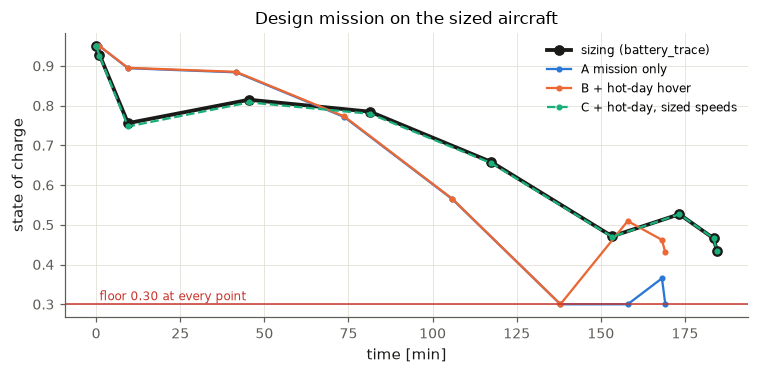

In [16]:
t, soc = [0.0], [ref.battery_trace[0]["soc_start"]]
for row in ref.battery_trace:
    t.append((row["time_start_s"] + row["duration_s"]) / 60); soc.append(row["soc_end"])
def trace(run):
    s, points = run["s"], [p for seg in run["flown"].segments for p in (seg.subsegments or (seg,))]
    tt, ss = [0.0], [soc_take_off]
    for p in points:
        tt.append(tt[-1] + float(s.value(p.duration_s)) / 60); ss.append(float(s.value(p.soc_end)))
    return tt, ss
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(t, soc, "o-", color=ink, lw=2.5, label="sizing (battery_trace)")
for (label, run), color, style in zip(runs.items(), (blue, orange, aqua), ("-", "-", "--")):
    ax.plot(*trace(run), style, marker=".", color=color, lw=1.5, label=label)
ax.axhline(soc_minimum, color=red, lw=1); ax.text(1, soc_minimum + 0.01, "floor 0.30 at every point", color=red, fontsize=8)
ax.set(xlabel="time [min]", ylabel="state of charge", title="Design mission on the sized aircraft")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Gotcha: `SegmentResult.point` is the first sub-point

`HaloSizingResult.segments` is built from `s.point` (halo_sizing.py L1356-1369), so for the cruise (four sub-points)
its battery share and powers are those of `"cruise 1/4"` only. The same holds for
`HaloSizingResult.lift_to_drag_cruise` and `cl_cruise` (L1350), and for the L/D fed to the structural design
condition (L1255). Verify on problem C:

In [17]:
s, flown_C = C["s"], C["flown"]
cruise_C = flown_C.segments[2]
print("cruise.point is cruise.subsegments[0].point:", cruise_C.point is cruise_C.subsegments[0].point)
print(f"{'cruise point':<12}{'h_e':>8}{'P_batt [kW]':>13}{'E_chem [kWh]':>14}{'L/D':>8}{'SOC end':>9}")
for p in cruise_C.subsegments:
    print(f"{p.point.condition.label:<12}{s.value(p.point.hybridization_electric):>8.4f}{s.value(p.point.power_battery_W) / 1e3:>13.1f}"
          f"{s.value(p.energy_battery_chemical_J) / 3.6e6:>14.2f}{s.value(p.point.aero.lift_to_drag):>8.3f}{s.value(p.soc_end):>9.4f}")
row = ref.segments[2]
print(f"\nbaseline().segments['cruise']: hybridization {row['hybridization']:.4f}, power_battery {row['power_battery_W'] / 1e3:.1f} kW, "
      f"battery {row['battery_kWh']:.2f} kWh (summed), SOC {ref.battery_trace[2]['soc_start']:.3f} -> {row['soc_end']:.3f}")
check("SegmentResult.point of a split segment is its first sub-point", cruise_C.point is cruise_C.subsegments[0].point)
check("baseline().segments cruise power_battery_W is the 'cruise 1/4' value of battery_trace",
      abs(row["power_battery_W"] - ref.battery_trace[2]["power_W"]) < 1e-6 and ref.battery_trace[2]["label"] == "cruise 1/4")
check("the first cruise sub-point charges (h_e < 0) while the cruise as a whole discharges",
      row["hybridization"] < 0 < row["battery_kWh"])
check("baseline().lift_to_drag_cruise is the first cruise sub-point's L/D",
      abs(s.value(cruise_C.subsegments[0].point.aero.lift_to_drag) - ref.lift_to_drag_cruise) < 1e-3)

cruise.point is cruise.subsegments[0].point: True
cruise point     h_e  P_batt [kW]  E_chem [kWh]     L/D  SOC end
cruise 1/4   -0.0100         -7.7         -4.58   9.065   0.8083
cruise 2/4    0.0049          3.6          2.18   9.116   0.7796
cruise 3/4    0.0213         15.4          9.24   9.160   0.6555
cruise 4/4    0.0313         22.0         13.27   9.198   0.4698

baseline().segments['cruise']: hybridization -0.0098, power_battery -7.4 kW, battery 20.65 kWh (summed), SOC 0.756 -> 0.471
PASS  SegmentResult.point of a split segment is its first sub-point
PASS  baseline().segments cruise power_battery_W is the 'cruise 1/4' value of battery_trace
PASS  the first cruise sub-point charges (h_e < 0) while the cruise as a whole discharges
PASS  baseline().lift_to_drag_cruise is the first cruise sub-point's L/D


The chain identities `build_mission` promises, checked on problem C: mass falls by the fuel burnt; each point
starts at the previous point's SOC; with the ECM the SOC change is I t / Q.

In [18]:
points = [p for seg in flown_C.segments for p in (seg.subsegments or (seg,))]
battery = instances["battery"].component
v = lambda x: float(s.value(x))
check("mass chain: end mass = start mass - total fuel burnt",
      abs(v(flown_C.mass_end_kg) - (v(points[0].mass_start_kg) - v(flown_C.mass_fuel_burnt_kg))) < 1e-6)
check("SOC chain: every point starts where the previous ended",
      all(abs(v(b.soc_start) - v(a.soc_end)) < 1e-12 for a, b in zip(points, points[1:])))
check("ECM: SOC drop = I t / Q at every point",
      all(abs(v(p.soc_start) - v(p.soc_end) - v(p.point.battery.current_A) * v(p.duration_s) / battery.capacity_As) < 1e-9
          for p in points))
net_chemical_kWh = v(flown_C.energy_battery_chemical_J) / 3.6e6
soc_drop_kWh = (soc_take_off - v(flown_C.soc_end)) * battery.energy_capacity_J / 3.6e6
print(f"net chemical energy drawn: {net_chemical_kWh:.2f} kWh; SOC drop x capacity: {soc_drop_kWh:.2f} kWh")
check("ECM: net chemical energy (OCV I t) differs from SOC drop x capacity (OCV above its mean at high SOC)",
      net_chemical_kWh > soc_drop_kWh)

PASS  mass chain: end mass = start mass - total fuel burnt
PASS  SOC chain: every point starts where the previous ended
PASS  ECM: SOC drop = I t / Q at every point
net chemical energy drawn: 38.04 kWh; SOC drop x capacity: 36.08 kWh
PASS  ECM: net chemical energy (OCV I t) differs from SOC drop x capacity (OCV above its mean at high SOC)


The last line matters for the cost model: the capacity is defined with the **mean** OCV over 0-1
(`battery_ecm.py` L243-246), while energy drawn at high SOC is at a higher OCV. So "SOC drop × capacity" (what the
cost uses for ground recharge) and "Σ OCV I t" (what it uses for throughput) are two different energies for the same
flight.

---
## 4. `mission/cost.py`

In [19]:
show_source("src/aircraft_closure/mission/cost.py")

# src/aircraft_closure/mission/cost.py  lines 1-93
   1  """Acquisition-plus-operating cost per mission (Tier 22, plan 029).
   2  
   3  The simplest useful direct-operating-cost form for an uncrewed hybrid-electric
   4  aircraft, written so every term is an AeroSandbox/CasADi expression of the
   5  sized design and the flown mission:
   6  
   7      cost per mission = capital + fuel + ground electricity + battery + time
   8  
   9  * capital: (airframe x price per kg + electric machines x price per W +
  10    turboshafts x price per W) / missions in the airframe life (straight-line
  11    depreciation, no interest, no residual value);
  12  * fuel: fuel burnt x fuel price;
  13  * ground electricity: the energy that restores the take-off SOC, at the
  14    charger efficiency, x the electricity price;
  15  * battery: pack price x (discharge throughput / cycle life + capacity /
  16    missions in the calendar life). Cycle ageing and calendar ageing add (a
  17    first-order a

**L1-26 docstring.** One formula (L7):
$$c_{mission} = c_{capital} + c_{fuel} + c_{electricity} + c_{battery} + c_{time}$$
- capital (L9-11): (airframe mass × USD/kg + electric machines rated W × USD/W + turboshafts rated W × USD/W) /
  missions in the airframe life. Straight-line depreciation, no interest, no residual value.
- fuel (L12): kg burnt × USD/kg.
- ground electricity (L13-14): the energy that restores the take-off SOC, divided by the charger efficiency.
- battery (L15-17): pack price × (throughput / cycle life + capacity / missions in the calendar life). Cycle and
  calendar ageing simply add.
- time (L18-19): mission duration × a lumped USD per flight hour (maintenance, remote crew, ground operations).
- L21-22: the pack price is **not** in capital; the battery term replaces it at the rate it is consumed.
- L24-25: an evaluator. No variables, no constraints, so the same object prices a numeric design or a symbolic one,
  and `objective="cost"` simply minimizes `per_mission_usd` (`halo_sizing.py` L1326-1327, scaled by USD 100).

**L30** `joule_per_kWh = 3.6e6`: prices are stated per kWh and stored per J (SI).

**L33-45 `CostBreakdown`**: acquisition (one aircraft, battery included) and five per-mission items; the total is a
property (L43-45), so it is always the sum of the items and works on symbols.

**L48-74 `CostModel` fields**, all labelled assumptions with an anchor in the comment:
USD 1,500/kg airframe (light rotorcraft list prices of 1,000-3,000 USD/kg); USD 150/kW machines with inverters;
USD 500/kW turboshafts; USD 500/kWh pack (about 4× the BloombergNEF 2024 automotive average); USD 0.90/kg Jet-A;
USD 0.15/kWh grid; charger 0.90; 1,000 equivalent full cycles; 3,750 calendar missions (8 years × about 470 per
year); 7,000 airframe missions (15 years × about 470); USD 500 per flight hour, stored per second.

**L76-93 `evaluate`.** L81 pack price = USD/J × capacity. L82-84 acquisition without the battery. L86 acquisition
adds the pack back. L87 capital excludes it. L88-92 the items as in the docstring. L79-80 docstring: *"Masses and
powers are aircraft totals"*. Keep that sentence in mind for Section 5.

The throughput / cycle-life term (L90): one equivalent full cycle costs one pack price over the cycle life,
whatever the pack size. A bigger pack cycled less deeply has the same cycle cost per kWh, but a larger calendar
cost (L91). Cycle life does not depend on depth of discharge (a stated limit, plan 029 deferred list).

---
## 5. The cost block of the sizing (examples/halo_sizing.py)

In [20]:
show_source("examples/halo_sizing.py", 1306, 1323)

# examples/halo_sizing.py  lines 1306-1323
1306      # ---- Cost per mission (Tier 22) -----------------------------------------------------------
1307      motor_component, generator_component = instances["motor"].component, instances["generator"].component
1308      turboshaft_component = instances["turboshaft"].component
1309      mass_airframe_kg = (breakdown.mass_empty_kg() - battery.get_mass()
1310                          - a.count_rotors * motor_component.get_mass()
1311                          - a.count_turbogenerators * (generator_component.get_mass() + turboshaft_component.get_mass()))
1312      energies_point_J = [p.energy_battery_chemical_J for s in flown.segments for p in (s.subsegments or (s,))]
1313      softness_energy_J = 1e-3 * design.energy_capacity_battery_J   # smooth max(E, 0): charge is not throughput
1314      cost = a.cost_model.evaluate(
1315          mass_airframe_kg=mass_airframe_kg,
1316          power_rated_machines_W=(a.count_rotors * motor_component.po

- **L1307-1308** the motor, generator and turboshaft components (one instance each; counts are on the topology).
- **L1309-1311** airframe mass = empty mass − battery − **count_rotors × one motor** − count_turbogenerators ×
  (generator + turboshaft). Everything else in the empty mass (rotors, gearboxes, wing, fuselage, systems, cables,
  heat exchanger, nacelles, generator gearboxes) is priced at the airframe rate.
- **L1312** the chemical energy of every mission sub-point (the per-point list, so charging and discharging points
  stay separate).
- **L1313, L1321** throughput = Σ softmax(E_i, 0) with a softness of 1e-3 × capacity: a smooth max(E_i, 0), so a
  charging point does not count as throughput (a charge is not wear here) and the expression stays differentiable.
- **L1316-1317** machine power = **count_rotors × one motor rating** + count_turbogenerators × generator rating.
- **L1318** turboshaft power = 2 × the fixed 1,120 hp rating.
- **L1322** ground recharge = (0.95 − landing SOC) × capacity.
- **L1323** duration = the mission duration (including the 20 min reserve loiter: the reserve is flown and paid for
  every mission).

**Run it:** reproduce `baseline().cost` from the rebuilt aircraft and `battery_trace`.

In [21]:
from aircraft_closure.mission.cost import CostBreakdown, CostModel, joule_per_kWh
a = assumptions
motor, generator, turboshaft = (instances[n].component for n in ("motor", "generator", "turboshaft"))
energies_point_J = [row["voltage_ocv_V"] * row["current_A"] * row["duration_s"] for row in ref.battery_trace]
softness_J = 1e-3 * ref.design.energy_capacity_battery_J
inputs = dict(
    mass_airframe_kg=(ref.mass_empty_kg - battery.get_mass() - a.count_rotors * motor.get_mass()
                      - a.count_turbogenerators * (generator.get_mass() + turboshaft.get_mass())),
    power_rated_machines_W=a.count_rotors * motor.power_rated_W + a.count_turbogenerators * generator.power_rated_W,
    power_rated_turboshafts_W=a.count_turbogenerators * ref.design.power_rated_turboshaft_W,
    energy_capacity_battery_J=ref.design.energy_capacity_battery_J,
    mass_fuel_burnt_kg=ref.mass_fuel_burnt_kg,
    energy_discharge_battery_J=float(sum(np.softmax(e, 0.0, softness=softness_J) for e in energies_point_J)),
    energy_recharge_ground_J=(soc_take_off - ref.soc_end) * ref.design.energy_capacity_battery_J,
    duration_mission_s=sum(row["duration_s"] for row in ref.segments))
cost = a.cost_model.evaluate(**inputs)
for name, value in inputs.items():
    print(f"  {name:<28} {value:,.1f}")
print(f"\n{'item':<16}{'reproduced':>14}{'baseline().cost':>17}")
for f in fields(CostBreakdown):
    print(f"{f.name:<16}{float(getattr(cost, f.name)):>14,.2f}{getattr(ref.cost, f.name):>17,.2f}")
print(f"{'per mission':<16}{float(cost.per_mission_usd):>14,.2f}{ref.cost.per_mission_usd:>17,.2f}")
check("CostModel.evaluate on the rebuilt aircraft reproduces every item of baseline().cost",
      all(abs(float(getattr(cost, f.name)) - getattr(ref.cost, f.name)) < 1e-6 * max(1, getattr(ref.cost, f.name))
          for f in fields(CostBreakdown)))
throughput_kWh, net_kWh = inputs["energy_discharge_battery_J"] / joule_per_kWh, sum(energies_point_J) / joule_per_kWh
print(f"\nthroughput {throughput_kWh:.2f} kWh (discharging points only) vs net {net_kWh:.2f} kWh; "
      f"ground recharge {inputs['energy_recharge_ground_J'] / joule_per_kWh:.2f} kWh")
check("throughput exceeds the net draw: the charging points (cruise 1/4, loiter) are excluded", throughput_kWh > net_kWh)
shares = {f.name: float(getattr(cost, f.name)) / float(cost.per_mission_usd) for f in fields(CostBreakdown) if f.name != "acquisition_usd"}
print("shares of the cost per mission:", {k: f"{v:.1%}" for k, v in shares.items()})

  mass_airframe_kg             3,657.3


  power_rated_machines_W       2,945,575.1
  power_rated_turboshafts_W    1,670,367.4
  energy_capacity_battery_J    251,978,083.6
  mass_fuel_burnt_kg           851.3
  energy_discharge_battery_J   167,087,235.4
  energy_recharge_ground_J     129,879,674.3
  duration_mission_s           11,070.6

item                reproduced  baseline().cost
acquisition_usd   6,797,968.31     6,797,968.31
capital_usd             966.14           966.14
fuel_usd                766.18           766.18
electricity_usd           6.01             6.01
battery_usd              32.54            32.54
time_usd              1,537.58         1,537.58
per mission           3,308.45         3,308.45
PASS  CostModel.evaluate on the rebuilt aircraft reproduces every item of baseline().cost

throughput 46.41 kWh (discharging points only) vs net 38.04 kWh; ground recharge 36.08 kWh
PASS  throughput exceeds the net draw: the charging points (cruise 1/4, loiter) are excluded
shares of the cost per mission: {'capital

Time is about 46 % of the cost per mission, capital about 29 %, fuel about 23 %; ground electricity and battery wear
together are about 1 %. This is why the cost optimum of plan 029 flies faster (210 kt vs 163 kt): time costs more
than fuel.

### Finding: the cost block counts one motor per rotor, but the Halo has two lane motors per rotor

With redundancy on (the default since plan 035), `motor` is **one lane motor** and the topology holds
`count_rotors × count_lanes_motor` copies (`powertrain/topologies.py` L77-82: `count_motors = count_rotors *
r.count_lanes`). `HaloSizingResult.power_rated_motor_W` is per lane (the field comment at L968-969 says so).
The cost block multiplies by `a.count_rotors` only (L1310 and L1316). Consequences:

- half of the motor mass stays in `mass_airframe_kg` and is priced at USD 1,500/kg as airframe;
- half of the motor rated power is missing from `power_rated_machines_W` (USD 150/kW);
- `CostModel.evaluate`'s docstring says the inputs are *aircraft totals*; these are not.

The generator count is right: `count_turbogenerators` equals the generator instance count (generators are not
laned). Quantify with the topology's own counts:

In [22]:
count_motors = instances["motor"].count
count_generators = instances["generator"].count
print(f"motor instances {count_motors} = count_rotors {a.count_rotors} x count_lanes_motor {ref.count_lanes_motor}; "
      f"generator instances {count_generators} = count_turbogenerators {a.count_turbogenerators}")
check("motor instance count = count_rotors x count_lanes_motor (not count_rotors)",
      count_motors == a.count_rotors * ref.count_lanes_motor == 4)
check("the motor mass in the powertrain breakdown is 4 lane motors, the cost removes 2",
      abs(dict(ref.powertrain_masses_kg)["motor"] - count_motors * motor.get_mass()) < 1e-6)
corrected_inputs = dict(inputs,
    mass_airframe_kg=inputs["mass_airframe_kg"] - (count_motors - a.count_rotors) * motor.get_mass(),
    power_rated_machines_W=count_motors * motor.power_rated_W + count_generators * generator.power_rated_W)
corrected = a.cost_model.evaluate(**corrected_inputs)
print(f"motor mass priced as airframe: {(count_motors - a.count_rotors) * motor.get_mass():.1f} kg; "
      f"motor power not priced: {(count_motors - a.count_rotors) * motor.power_rated_W / 1e3:.0f} kW")
print(f"acquisition {ref.cost.acquisition_usd:,.0f} -> {float(corrected.acquisition_usd):,.0f} USD "
      f"({float(corrected.acquisition_usd) - ref.cost.acquisition_usd:+,.0f})")
print(f"per mission {ref.cost.per_mission_usd:,.2f} -> {float(corrected.per_mission_usd):,.2f} USD "
      f"({float(corrected.per_mission_usd) - ref.cost.per_mission_usd:+,.2f}, capital only)")
specific_power_W_kg = motor.power_rated_W / motor.get_mass()
bug_usd_W = a.count_rotors * (a.cost_model.price_machine_usd_W + a.cost_model.price_airframe_usd_kg / specific_power_W_kg)
right_usd_W = count_motors * a.cost_model.price_machine_usd_W
print(f"lane motor {specific_power_W_kg:.0f} W/kg; motors priced at {bug_usd_W:.3f} USD per W of lane rating "
      f"instead of {right_usd_W:.3f}")
check("the bug overprices the motors by (bug - right) x lane rating = the acquisition difference",
      abs((bug_usd_W - right_usd_W) * motor.power_rated_W - (ref.cost.acquisition_usd - float(corrected.acquisition_usd))) < 1e-3)
check("the correction changes only the capital item (and acquisition)",
      all(abs(float(getattr(corrected, n)) - float(getattr(cost, n))) < 1e-9 for n in ("fuel_usd", "electricity_usd", "battery_usd", "time_usd")))

motor instances 4 = count_rotors 2 x count_lanes_motor 2; generator instances 2 = count_turbogenerators 2
PASS  motor instance count = count_rotors x count_lanes_motor (not count_rotors)
PASS  the motor mass in the powertrain breakdown is 4 lane motors, the cost removes 2
motor mass priced as airframe: 212.8 kg; motor power not priced: 1056 kW
acquisition 6,797,968 -> 6,637,136 USD (-160,832)
per mission 3,308.45 -> 3,285.48 USD (-22.98, capital only)
lane motor 4961 W/kg; motors priced at 0.905 USD per W of lane rating instead of 0.600
PASS  the bug overprices the motors by (bug - right) x lane rating = the acquisition difference
PASS  the correction changes only the capital item (and acquisition)


The effect on the baseline's reported cost is small (about −23 USD of 3,308 USD per mission, −0.7 %). Two lane
motors are priced as airframe at 1,500 USD/kg (about 319 kUSD) instead of as machines at 150 USD/kW (about
158 kUSD; the lane motor is about 5 kW/kg). The baseline is a mass optimum, so its *design* is unaffected. In an
`objective="cost"` solve the motor price gradient is wrong: per W of lane-motor rating the bug charges
2 × 0.15 + 2 × 1,500 / 4,960 ≈ 0.9 USD/W against the correct 4 × 0.15 = 0.6 USD/W, so motors look about 50 % more
expensive than they are. Any study that changes `count_lanes_motor` gets the motor cost wrong. The fix is to use
the topology counts: `instances["motor"].count` and `instances["generator"].count` (or
`a.count_rotors * count_lanes_motor(a)`).

---
## Gotchas

- **`SegmentResult.point` is the first sub-point** of a split segment (mission.py L137). `HaloSizingResult.segments`
  (battery share, powers, motor speed and torque), `lift_to_drag_cruise`, `cl_cruise` and the structural design
  condition's L/D (halo_sizing.py L1255) all read the first quarter of the cruise. Use `battery_trace` or the
  `subsegments` for anything integrated over a segment.
- **Hover segments are T/W = 1** (segments.py L34); the T/W 1.05 margin is a requirement, not a mission segment.
- **Requirement points are at SOC 0.8**, the `FlightCondition` default (capability.py L24-28 passes no SOC). Nothing in
  `HaloRequirements` sets it.
- **`build_mission` constrains only the SOC window and thrust ≥ 0.** The margins come back unconstrained; the
  caller must write `m.value >= 0`, fuel sufficiency and any end-SOC condition (as `fly()` does above).
- **Start-state evaluation:** each point is held at its start mass and SOC for its interval, so fuel is slightly
  overestimated and OCV lags (the reason for 4 cruise sub-points).
- **`halo_mission()` defaults** (`velocity_cruise_m_s=None`) build a mission whose cruise duration raises
  `TypeError`; always pass speeds (numbers or variables).
- **Two different battery energies:** throughput uses Σ OCV I t, ground recharge uses ΔSOC × capacity (mean-OCV
  capacity). For the sized mission they differ by a few kWh.
- **The battery share at a capability point is not unique** (hover requirement feasible from about 0.10 to 0.49):
  read it as "a feasible split".
- **The sized mission depends on constraints outside the mission:** flown alone, the same aircraft lands at the
  0.30 floor (the hot-day hover is missing) and cruises faster (the structural penalty of speed is missing), for
  about 21 kg less fuel.

## Limits / what it can't do

- Quasi-steady points only: no acceleration, conversion or transition segments, no wind, no taxi, no alternate
  airport; climb and descent at the mean altitude (plan 009).
- One mission per solve; no multi-mission design (plan 010).
- Failure states only on hover segments; requirements have no degraded states other than `active_rotor_count`.
- Cost: no interest, residual value, insurance or fees; cycle life independent of depth of discharge; prices are
  assumptions, not Halo or Archer data (plan 029).

## What's next (docs/NEXT_STEPS.md, plan 029 deferred)

- Payload-range and endurance: sweep payload at the fixed design (the `fly()` pattern above is the building block).
- A cost-mass Pareto front; cycle life against depth of discharge.
- Fix the lane count in the cost block (this notebook's finding).

## Findings

1. **Cost block lane count** (`examples/halo_sizing.py` L1310, L1316): `a.count_rotors × motor` instead of the
   topology's `count_rotors × count_lanes_motor` motors. Two lane motors (213 kg) are priced as airframe and
   1,056 kW of motor rating is not priced; acquisition is 161 kUSD too high and capital about 23 USD per mission too
   high. Contradicts `CostModel.evaluate`'s "aircraft totals" docstring (`cost.py` L79-80).
2. **`SegmentResult.point` / reported segment values** (`mission.py` L137; `halo_sizing.py` L1350, L1356-1369,
   L1255): reported cruise battery share is −0.0098 (charging) while the cruise draws 20.6 kWh; the cruise L/D used
   in the structural condition is the first sub-point's. Documented in the code comment (L42) but easy to misread.
3. **Hidden SOC of the requirement points** (`capability.py` L24-28): the hover requirement is evaluated at SOC 0.8 by
   default, a modelling assumption that is not exposed in `HaloRequirements`.
4. **`halo_mission` default arguments** (`halo_sizing.py` L901): `None` speeds are not a usable default.

## Review questions

<details><summary>Why do sustained requirements default to h_e = 0 while hover is free?</summary>

A requirement is a point with no duration, so no energy budget limits the battery there. With a free split the
optimizer could meet 210 kt on battery power and shrink the turboshafts and generators; nothing would pay for the
energy. Sustained capability must come from fuel. Hover lasts about a minute, and the battery may assist it (plan
008, plan 017).
</details>

<details><summary>Why hold the SOC floor at every segment end, not only at landing?</summary>

The engine-out hover reserve is assessed from SOC 0.30. With in-flight recharging allowed, the optimizer could dip
below 0.30 mid-mission and recharge later; an engine failure at the bottom of the dip would find less than the
reserve. Plan 017 found SOC at 0.20 in cruise before `soc_floor_every_segment` was added (mission.py L126).
</details>

<details><summary>Why does the sized aircraft, flown alone on its design mission, land at 0.30 instead of 0.435?</summary>

The sizing also contains the hot-day hover at the destination, which starts from the landing SOC, end mass and end
temperatures and must end at ≥ 0.10. In the hot day the engines lapse and the battery supplies part of the hover,
so the sizing lands with charge in hand. Adding that hover to the stand-alone problem (B) restores the landing SOC
for about 3 kg of fuel; fixing the speeds as well (C) reproduces the sized fuel. Most of the 21 kg fuel difference
is the faster cruise the frozen aircraft can afford.
</details>

<details><summary>How does a mission become "semi-free" without any special code?</summary>

Segment fields are typed `Any`. Passing an Opti variable for a speed makes the duration (distance / V), the flight
condition, the fuel burnt and the SOC drop symbolic. The battery share is free whenever `hybridization_electric` is
`None`: the flight point creates the variable. `build_mission` chains whatever it receives.
</details>

<details><summary>Why is throughput a smooth max per point rather than the net battery energy?</summary>

Wear is driven by discharge throughput; a charging point (negative chemical energy) should not reduce it.
Σ max(E_i, 0) per sub-point keeps charging and discharging separate; `np.softmax` with a softness of 1e-3 of the
capacity keeps it differentiable for IPOPT. On the baseline the throughput is larger than the net draw because
cruise 1/4 and the loiter charge.
</details>

<details><summary>What is wrong with the motor terms in the cost block, and how large is it?</summary>

With redundancy the topology has count_rotors × count_lanes = 4 lane motors, but the cost uses count_rotors = 2.
Two lane motors (213 kg) are priced as airframe and their 1,056 kW rating is not priced as machines: acquisition
+161 kUSD, capital +23 USD per mission (0.7 %). Use `instances["motor"].count`.
</details>

In [23]:
check_summary()

30 of 30 checks passed
